In [1]:
from plot_tmi_results import compute_tmi_from_singular_values
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import h5py
import csv
from FSS.DataCollapse import *
from read_tmi_results import read_tmi_results, bootstrap_data_collapse

In [2]:
p_fixed = 0.000
results = read_tmi_results(p_fixed=p_fixed, p_fixed_name='pproj', thresholds=None)

In [5]:
L_min = 12
delta_p = 0.05
p_c = 0.2
thresholds = sorted(list(results.keys()))
threshold_index = 0
print(thresholds[threshold_index])
df = results[thresholds[threshold_index]]
bootstrap_results = bootstrap_data_collapse(
        df=df,  # Use first threshold's data
        n_samples=100,
        sample_size=1000,
        p_c=p_c,
        nu=0.7,
        L_min=L_min,
    )

print("\nBootstrap Analysis Results:")
print(f"nu = {bootstrap_results['nu_mean']:.3f} ± {bootstrap_results['nu_std']:.3f}")
print(f"p_c = {bootstrap_results['pc_mean']:.3f} ± {bootstrap_results['pc_std']:.3f}")
print(f"reduced chi^2 = {bootstrap_results['redchi_mean']:.3f} ± {bootstrap_results['redchi_std']:.3f}")

1e-15


ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

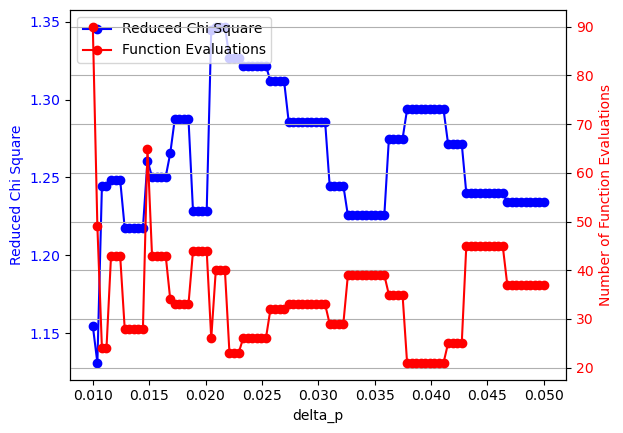

In [6]:
delta_p_values = np.linspace(0.01, 0.05, 100)
redchi_values = []
num_func_evals = []

for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=0.7, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    redchi_values.append(dc.res.redchi)
    num_func_evals.append(dc.res.nfev)
fig, ax1 = plt.subplots()

# Plot redchi on left y-axis
ax1.plot(delta_p_values,redchi_values, 'o-', color='blue', label='Reduced Chi Square')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('Reduced Chi Square', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot nfev
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_func_evals, 'o-', color='red', label='Function Evaluations')
ax2.set_ylabel('Number of Function Evaluations', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid()
plt.show()

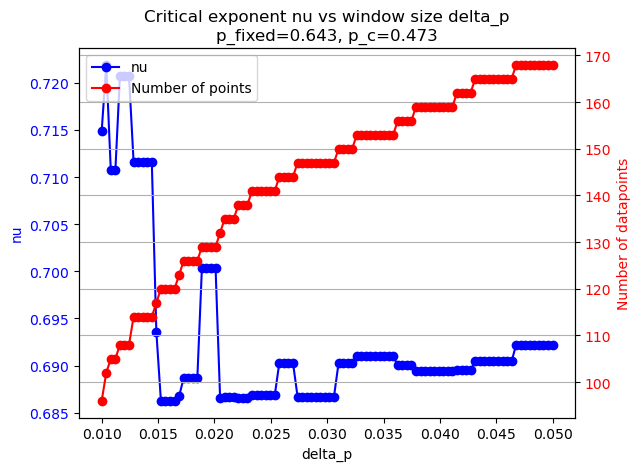

In [7]:
# Extract nu values and number of points for different delta_p
nu_values = []
num_points = []
for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=0.7, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    nu_values.append(dc.nu)
    num_points.append(len(dc.y_i))

fig, ax1 = plt.subplots()

# Plot nu on left y-axis
ax1.plot(delta_p_values, nu_values, 'o-', color='blue', label='nu')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('nu', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot number of points
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_points, 'o-', color='red', label='Number of points')
ax2.set_ylabel('Number of datapoints', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Critical exponent nu vs window size delta_p\np_fixed={p_fixed:.3f}, p_c={p_c:.3f}')
plt.grid()
plt.show()


In [8]:
# # Create error bar plot for different L values
# for threshold in thresholds:
#     df = results[threshold]
#     # Get both mean and standard error
#     df_stats = df['observations'].apply(lambda x: pd.Series({
#     'mean': np.mean(x),
#     'std': np.std(x),
#     'sem': np.std(x) / np.sqrt(len(x))  # standard error of the mean
#     }))
    
#     fig, ax = plt.subplots()
#     for L in [8, 12, 16, 20]:
#         # Plot with error bars
#         ax.errorbar(df_stats.index.get_level_values('p').unique(), df_stats['mean'].xs(L, level='L'), yerr=df_stats['sem'].xs(L, level='L'), label=f'L={L}', marker='o')
    
#     ax.legend()
#     ax.set_xlabel('p')
#     ax.set_ylabel('TMI')
#     ax.set_title(f'TMI vs p for threshold={threshold:.1e}')
#     ax.grid()
#     plt.show()

In [10]:
# Print unique combinations of p and L values
print("Unique (p, L) combinations in the dataset:")
print("\np values:", sorted(df.index.get_level_values('p').unique()))
print("\nL values:", sorted(df.index.get_level_values('L').unique()))


Unique (p, L) combinations in the dataset:

p values: [0.43, 0.4352631578947368, 0.4405263157894736, 0.4457894736842105, 0.4499999999999999, 0.4510526315789473, 0.4521052631578947, 0.4542105263157894, 0.4563157894736842, 0.4584210526315789, 0.4605263157894737, 0.461578947368421, 0.4626315789473684, 0.4629999999999999, 0.4640526315789473, 0.4647368421052631, 0.4651052631578947, 0.466157894736842, 0.4668421052631578, 0.4668421052631579, 0.4672105263157894, 0.4682631578947368, 0.4689473684210526, 0.4693157894736842, 0.4703684210526315, 0.4710526315789473, 0.4714210526315789, 0.4721052631578947, 0.4724736842105262, 0.473157894736842, 0.4735263157894737, 0.474578947368421, 0.4752631578947368, 0.4756315789473684, 0.4766842105263157, 0.4773684210526315, 0.4773684210526316, 0.4777368421052631, 0.4787894736842105, 0.4794736842105263, 0.4798421052631578, 0.4808947368421052, 0.481578947368421, 0.4819473684210526, 0.4826315789473684, 0.483, 0.4836842105263157, 0.4857894736842105, 0.487894736842105

In [11]:
# try larger sample size
# denser p scan resolutions closer to pc -- plot the profile of the data collapse, need larger delta_p to detect curvature in the data
# try different threshold -- as related to pc and nu

# bootstrapping?
# summer funding?


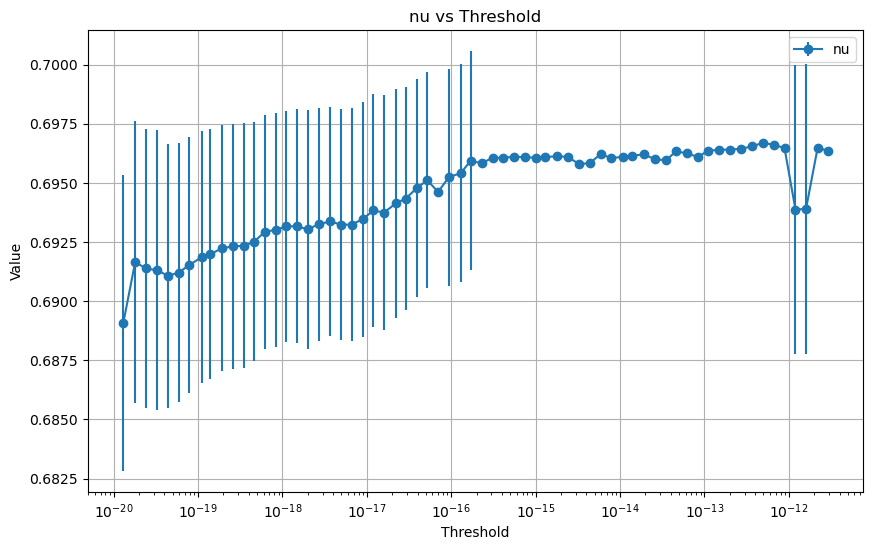

1e-20 0.6894880173192179 0.0015380082329815954
1.3e-20 0.6890688636814452 0.006251964012931711
1.8e-20 0.6916559374591494 0.0059755389330673776
2.4e-20 0.6913824012021945 0.0058837324082622825
3.3e-20 0.6913065437779193 0.0059136565564328085
4.4e-20 0.6910695218871028 0.005567290598602942
5.9e-20 0.6912093216754176 0.005480999935901923
7.9e-20 0.6915308498476173 0.005403948498176515
1.1e-19 0.6918539908768937 0.005321290659443649
1.4e-19 0.6919849521298339 0.0052704718836972956
1.9e-19 0.6922269449495746 0.005198247532491012
2.6e-19 0.6923184662187819 0.0051696655490751225
3.5e-19 0.6923401603140019 0.005170469717060191
4.6e-19 0.6925066318104618 0.005053819326298208
6.2e-19 0.6929354672003543 0.00493790762863997
8.4e-19 0.693012877930739 0.00494140419275211
1.1e-18 0.6931611080817253 0.004896565478732998
1.5e-18 0.6931651436705397 0.004954184045988034
2e-18 0.6930305775265558 0.0050440393805483005
2.7e-18 0.6932576873237368 0.004921785438865349
3.7e-18 0.6933689075511391 0.00483876466

In [7]:
from FSS.DataCollapse import *

p_c = 0.473
delta_p = 0.05
L_min = 12
threshold_values = []
nu_values = []
nu_std = []
pc_values = []
pc_std = []
redchi_values = []
for threshold in thresholds:
    df = results[threshold]
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=0.7, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    nu_values.append(dc.res.params['nu'].value)
    nu_std.append(dc.res.params['nu'].stderr)
    pc_values.append(dc.res.params['p_c'].value)
    pc_std.append(dc.res.params['p_c'].stderr)
    redchi_values.append(dc.res.redchi)
    threshold_values.append(threshold)

# Get indices where redchi < 10
good_indices = np.where(np.array(redchi_values) < 10)

# Now you can use these indices to get the corresponding values
good_thresholds = np.array(threshold_values)[good_indices]
good_nu = np.array(nu_values)[good_indices]
good_nu_std = np.array(nu_std)[good_indices]
good_pc = np.array(pc_values)[good_indices]
good_pc_std = np.array(pc_std)[good_indices]
good_redchi = np.array(redchi_values)[good_indices]

# Create figure with one subplot
plt.figure(figsize=(10,6))
# Plot both nu and pc vs threshold on same axes
plt.semilogx()  # Set x-axis to log scale
plt.errorbar(good_thresholds, good_nu, yerr=good_nu_std, fmt='o-', label='nu')
# plt.errorbar(good_thresholds, good_pc, yerr=good_pc_std, fmt='o-', label='p_c')
# plt.errorbar(good_thresholds, good_redchi, fmt='o-', label='Reduced Chi Square')
plt.xlabel('Threshold')
plt.ylabel('Value') 
plt.title('nu vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

for threshold, nu, nu_std in zip(thresholds, nu_values, nu_std):
    print(threshold, nu, nu_std)

lower_bound_threshold = 1e-10
upper_bound_threshold = 1e-8



In [13]:
delta_p_range = np.linspace(0.01, 0.05, 100)
threshold_values = list(results.keys())  # Convert dict_keys to list

# Create arrays to store results for each delta_p and threshold combination
redchi_map = np.zeros((len(delta_p_range), len(threshold_values)))
nu_map = np.zeros_like(redchi_map)
pc_map = np.zeros_like(redchi_map)

# Loop over all combinations of delta_p and thresholds
for i, delta_p in enumerate(delta_p_range):
    for j, threshold in enumerate(threshold_values):
        dc = DataCollapse(results[threshold], p_='p', L_='L', params={}, 
                         p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
        dc.datacollapse(p_c=p_c, nu=0.7, beta=0., 
                       p_c_vary=True, beta_vary=False, nu_vary=True, 
                       max_nfev=1000)
        redchi_map[i,j] = dc.res.redchi
        nu_map[i,j] = dc.res.params['nu'].value
        pc_map[i,j] = dc.res.params['p_c'].value

Text(0.5, 1.0, 'p_c')

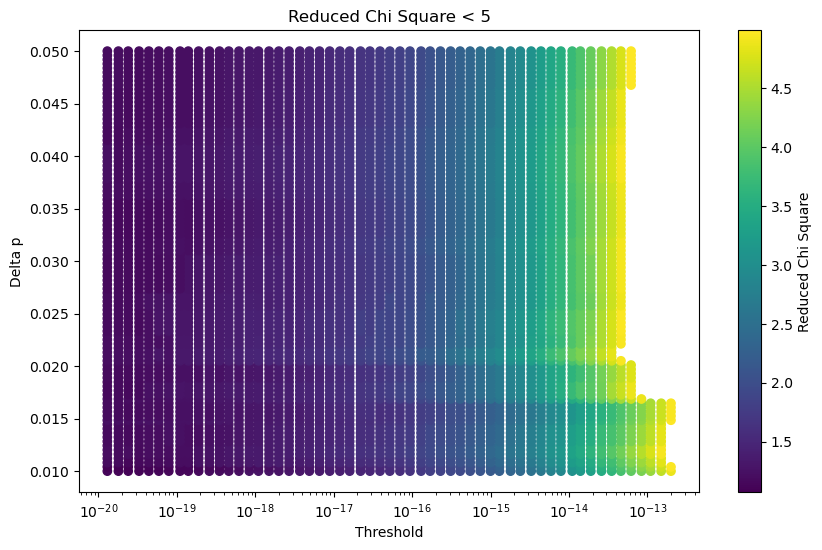

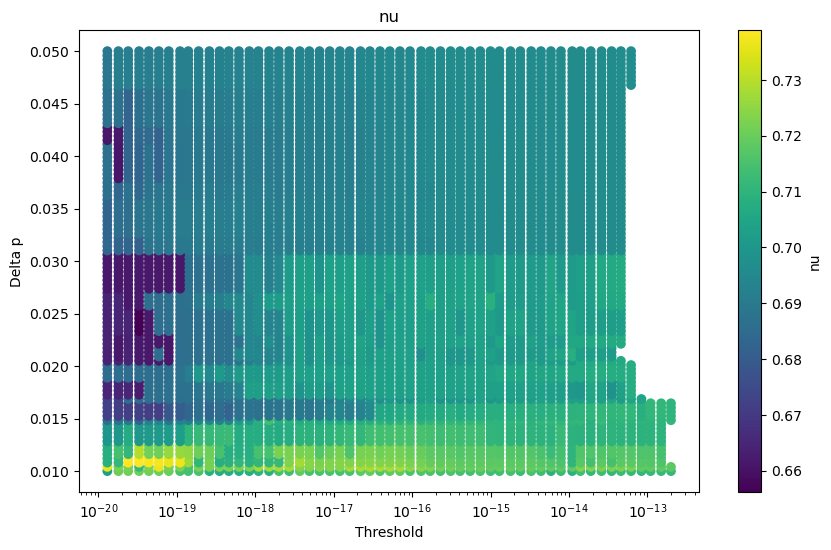

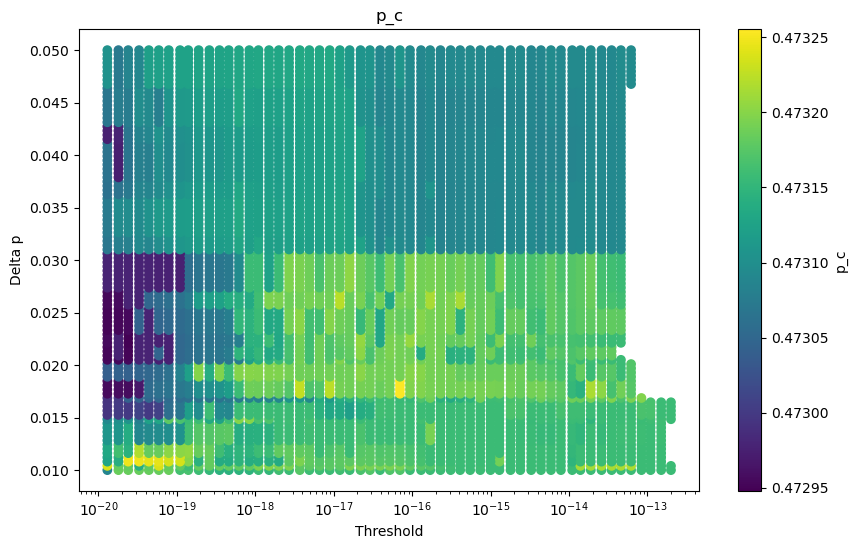

In [14]:
# Create figure with 3 subplots
plt.figure(figsize=(10,6))

# First subplot - Reduced Chi Square
# plt.subplot(1,3,1)
X, Y = np.meshgrid(threshold_values, delta_p_range)
# Create mask for redchi values less than cutoff
cutoff = 5
mask = redchi_map < cutoff
# Plot only points where redchi < 10
plt.scatter(X[mask], Y[mask], c=np.transpose(redchi_map[mask]), cmap='viridis')
plt.colorbar(label='Reduced Chi Square')
plt.ylabel('Delta p')
plt.xlabel('Threshold') 
plt.xscale('log')
plt.title(f'Reduced Chi Square < {cutoff}')

# Create figure with 3 subplots
plt.figure(figsize=(10,6))

# First subplot - Reduced Chi Square
# plt.subplot(1,3,1)
# Plot only points where redchi < 10
plt.scatter(X[mask], Y[mask], c=np.transpose(nu_map[mask]), cmap='viridis')
plt.colorbar(label='nu')
plt.ylabel('Delta p')
plt.xlabel('Threshold') 
plt.xscale('log')
plt.title('nu')

# Create figure with 3 subplots
plt.figure(figsize=(10,6))

# First subplot - Reduced Chi Square
# plt.subplot(1,3,1)
# Plot only points where redchi < 10
plt.scatter(X[mask], Y[mask], c=np.transpose(pc_map[mask]), cmap='viridis')
plt.colorbar(label='p_c')
plt.ylabel('Delta p')
plt.xlabel('Threshold') 
plt.xscale('log')
plt.title('p_c')



In [15]:
for threshold in good_thresholds:
    df = results[threshold]
    dc = DataCollapse(df, p_='p', L_='L', params={}, 
                     p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., 
                   p_c_vary=True, beta_vary=False, nu_vary=True, 
                   max_nfev=1000)
    # print(dc.res.params['nu'].value)
    # print(dc.res.params['p_c'].value)
    print(dc.res.redchi)
    break

1.5352320477698311
